In [1]:
try:
    %reload_ext autoreload
except:
    %load_ext autoreload
%autoreload 2

# Basic useful imports
import re
import time
import yaml
from pprint import pprint
from pathlib import Path
import h5py
import warnings

# Data manipulation
import numpy as np
from scipy.special import erf
from scipy.integrate import quad, solve_ivp
import scipy.stats as stats
from scipy.signal import savgol_filter
from scipy.spatial import ConvexHull

# Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import (Circle, RegularPolygon, FancyArrowPatch, ArrowStyle)
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator, NullFormatter)
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

# Clustering stuff
from sklearn.cluster import MeanShift, estimate_bandwidth, DBSCAN, OPTICS
from itertools import cycle
# plt.cm.tab20.colors

# From alens_analysis.py
import alens_analysis as aa
import alens_analysis.chromatin as aac
import alens_analysis.chromatin.chrom_analysis as ca
import alens_analysis.chromatin.chrom_condensate_analysis as cca
import alens_analysis.chromatin.chrom_graph_funcs as cgf
from alens_analysis import cluster_analysis as cla

from alens_analysis.colormaps import register_cmaps

# Functions for my simulations
from dyn_cond_fig_functions import *


# Locations
ws_path = Path('/home/alamson/DATA/Chromatin/')
mnt_path = Path.home() / 'projects/DATA/Chromatin/'
ceph_path = Path.home() / 'ceph/DATA/Chromatin/'

In [13]:
def bin_data(time_arr, data_arr, bin_size=10.0):
    """
    Bin data by time intervals.
    
    Parameters
    ----------
    time_arr : array-like
        Time values
    data_arr : array-like
        Data values to bin
    bin_size : float
        Size of time bins in seconds (default: 10.0)
    
    Returns
    -------
    binned_time : array
        Centers of time bins
    binned_data : array
        Averaged data within each bin
    """
    # Create bin edges
    min_time = time_arr[0]
    max_time = time_arr[-1]
    bin_edges = np.arange(min_time, max_time + bin_size, bin_size)
    
    # Digitize to find which bin each time point belongs to
    bin_indices = np.digitize(time_arr, bin_edges)
    
    # Calculate mean for each bin
    binned_time = []
    binned_data = []
    
    for i in range(1, len(bin_edges)):
        mask = bin_indices == i
        if np.any(mask):
            binned_time.append(np.mean(time_arr[mask]))
            binned_data.append(np.mean(data_arr[mask]))
    
    return np.array(binned_time), np.array(binned_data)

### Style settings

In [14]:
graph_sty = {
    "axes.titlesize": 20,
    "axes.labelsize": 24,
    "lines.linewidth": 2,
    "lines.markersize": 10,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "font.size": 20,
    # "font.sans-serif": 'Helvetica',
    "text.usetex": False,
    'mathtext.fontset': 'cm',
}
plt.style.use(graph_sty)

colors = cycle(mcolors.XKCD_COLORS.keys())

plt.rcParams['image.cmap'] = 'YlOrRd'
        

[0.0000e+00 0.0000e+00 5.0000e-01 ... 4.1985e+03 4.1990e+03 4.1995e+03]


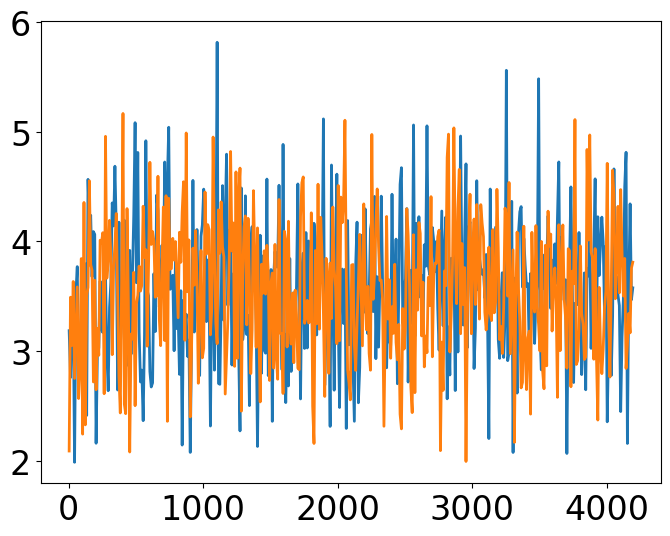

In [15]:
data_path = (ceph_path /"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin5.0um/s1/analysis")
bead_window = 11 
ss_ind = 0
end_ind = -1
start_bead = 0
end_bead = -1
fig, ax = plt.subplots(figsize=(8,6))
with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
    time_arr = h5_data['time'][ss_ind:end_ind]
    print(time_arr)
    tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
binned_time_0, binned_tension_0 = bin_data(time_arr, tension_arr[0,:], bin_size=10.0)
binned_time_1, binned_tension_1 = bin_data(time_arr, tension_arr[-1,:], bin_size=10.0)
_ = ax.plot(binned_time_0, binned_tension_0)
_ = ax.plot(binned_time_1, binned_tension_1)

[0.0000e+00 0.0000e+00 5.0000e-01 ... 4.1985e+03 4.1990e+03 4.1995e+03]


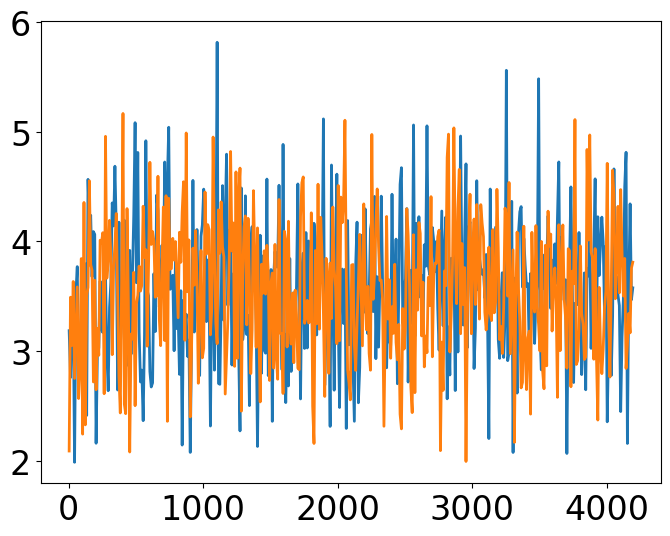

In [ ]:
data_path = (ceph_path /"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin5.0um/s1/analysis")
bead_window = 11 
ss_ind = 0
end_ind = -1
start_bead = 0
end_bead = -1
fig, ax = plt.subplots(figsize=(8,6))
with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
    time_arr = h5_data['time'][ss_ind:end_ind]
    print(time_arr)
    tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
binned_time_0, binned_tension_0 = bin_data(time_arr, tension_arr[0,:], bin_size=30.0)
binned_time_1, binned_tension_1 = bin_data(time_arr, tension_arr[-1,:], bin_size=10.0)
_ = ax.plot(binned_time_0, binned_tension_0)
_ = ax.plot(binned_time_1, binned_tension_1)

[0.0000e+00 0.0000e+00 5.0000e-01 ... 4.1985e+03 4.1990e+03 4.1995e+03]


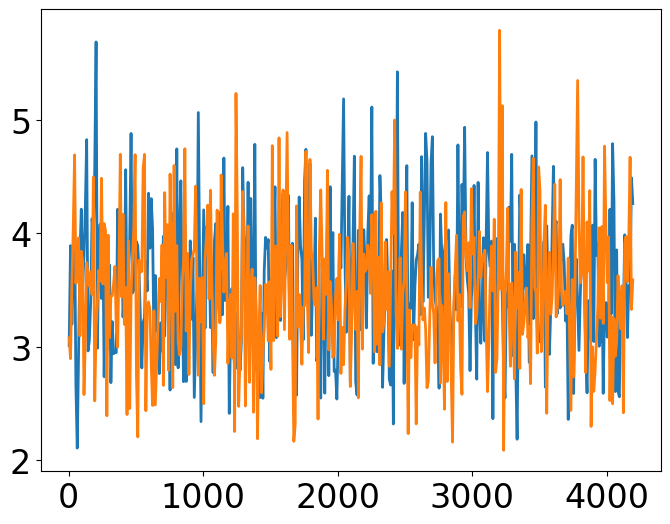

In [17]:
data_path = (ceph_path /"DynCondPaper/24-03-08_aLc1_slice5.5.13_line1600_Pin3-11um_2xKe3-300_ks100/simulations/Ke30_Pin5.0um/s3/analysis")
bead_window = 11 
ss_ind = 0
end_ind = -1
start_bead = 0
end_bead = -1
fig, ax = plt.subplots(figsize=(8,6))
with h5py.File(next(data_path.glob('raw_data.h5')), 'r+') as h5_data:
    time_arr = h5_data['time'][ss_ind:end_ind]
    print(time_arr)
    tension_arr = aa.get_link_tension(h5_data)[:,ss_ind:end_ind]
binned_time_0, binned_tension_0 = bin_data(time_arr, tension_arr[0,:], bin_size=10.0)
binned_time_1, binned_tension_1 = bin_data(time_arr, tension_arr[-1,:], bin_size=10.0)
_ = ax.plot(binned_time_0, binned_tension_0)
_ = ax.plot(binned_time_1, binned_tension_1)

# Figure 6a